# **Analysis 1: Platform Level Analysis**

## **Data Assembly**

The dataset was obtained using Stack Exchange Data Explorer (SEDE). A SQL query was used to extract monthly activity data from Stack Overflow. The goal was to analyze how platform activity changed after the emergence of modern AI chatbots such as ChatGPT, Claude, Gemini, Copilot, and Perplexity.

Because retrieving every individual question from Stack Overflow would produce an extremely large dataset, the query aggregated the data monthly. This allowed the analysis to focus on trends in platform activity over time.

The dataset covers the period 2018–2025.

data - https://data.stackexchange.com/stackoverflow/query/edit/1940300


### **SQL Query Used for Extraction**

```sql
SELECT
  YEAR(q.CreationDate) AS [Year],
  MONTH(q.CreationDate) AS [Month],
  COUNT(*) AS NumQuestions,
  SUM(CASE WHEN q.AnswerCount > 0 THEN 1 ELSE 0 END) AS AnsweredQuestions,
  1.0 * SUM(CASE WHEN q.AnswerCount > 0 THEN 1 ELSE 0 END) / COUNT(*) AS AnswerRate,
  SUM(CASE WHEN q.AcceptedAnswerId IS NOT NULL THEN 1 ELSE 0 END) AS AcceptedQuestions,
  1.0 * SUM(CASE WHEN q.AcceptedAnswerId IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*) AS AcceptedRate,
  AVG(CASE WHEN q.AcceptedAnswerId IS NULL THEN NULL
           ELSE DATEDIFF(MINUTE, q.CreationDate, a.CreationDate) END) AS AvgMinutesToAccepted
FROM Posts q
LEFT JOIN Posts a ON a.Id = q.AcceptedAnswerId
WHERE q.PostTypeId = 1
  AND q.CreationDate >= '2018-01-01'
GROUP BY YEAR(q.CreationDate), MONTH(q.CreationDate)
ORDER BY [Year], [Month];

### **Importing the Dataset**

### **Loading Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from datetime import datetime, timedelta
from scipy.stats import ttest_ind

In [2]:
link = "https://raw.githubusercontent.com/hima0921/stack-overflow-ai-project/main/data/Dataset_A.csv"

df = pd.read_csv(link)

df.head()

,Year,Month,NumQuestions,AnsweredQuestions,AnswerRate,AcceptedQuestions,AcceptedRate,AvgMinutesToAccepted
0,2018,1,160527,134597,0.838470,76188,0.474612,16019
1,2018,2,153132,128411,0.838564,72805,0.475439,15905
2,2018,3,172986,144183,0.833495,80993,0.468206,15440
3,2018,4,162468,134944,0.830588,75298,0.463464,15420
4,2018,5,167776,138609,0.826155,77180,0.460018,15809


## **Understanding the Dataset**

In [3]:
print(df.columns)

Index(['Year', 'Month', 'NumQuestions', 'AnsweredQuestions', 'AnswerRate',
       'AcceptedQuestions', 'AcceptedRate', 'AvgMinutesToAccepted'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  98 non-null     int64  
 1   Month                 98 non-null     int64  
 2   NumQuestions          98 non-null     int64  
 3   AnsweredQuestions     98 non-null     int64  
 4   AnswerRate            98 non-null     float64
 5   AcceptedQuestions     98 non-null     int64  
 6   AcceptedRate          98 non-null     float64
 7   AvgMinutesToAccepted  98 non-null     int64  
dtypes: float64(2), int64(6)
memory usage: 6.3 KB


### **Dataset Description**

The key variables/columns in the dataset are:

NumQuestions – total number of questions posted during that month.

AnsweredQuestions – number of questions that received at least one answer.

AnswerRate – proportion of questions that received answers.

AcceptedQuestions – number of questions where an answer was accepted by the original poster.

AcceptedRate – proportion of questions with an accepted answer.

AvgMinutesToAccepted – average time (in minutes) required for a question to receive an accepted answer.


## **Analyzing the Dataset**

### **Visualizing the Drop in Question Volume**

The visualization tracks the overall volume of questions over time, with vertical reference lines indicating the release dates of major AI chatbots.

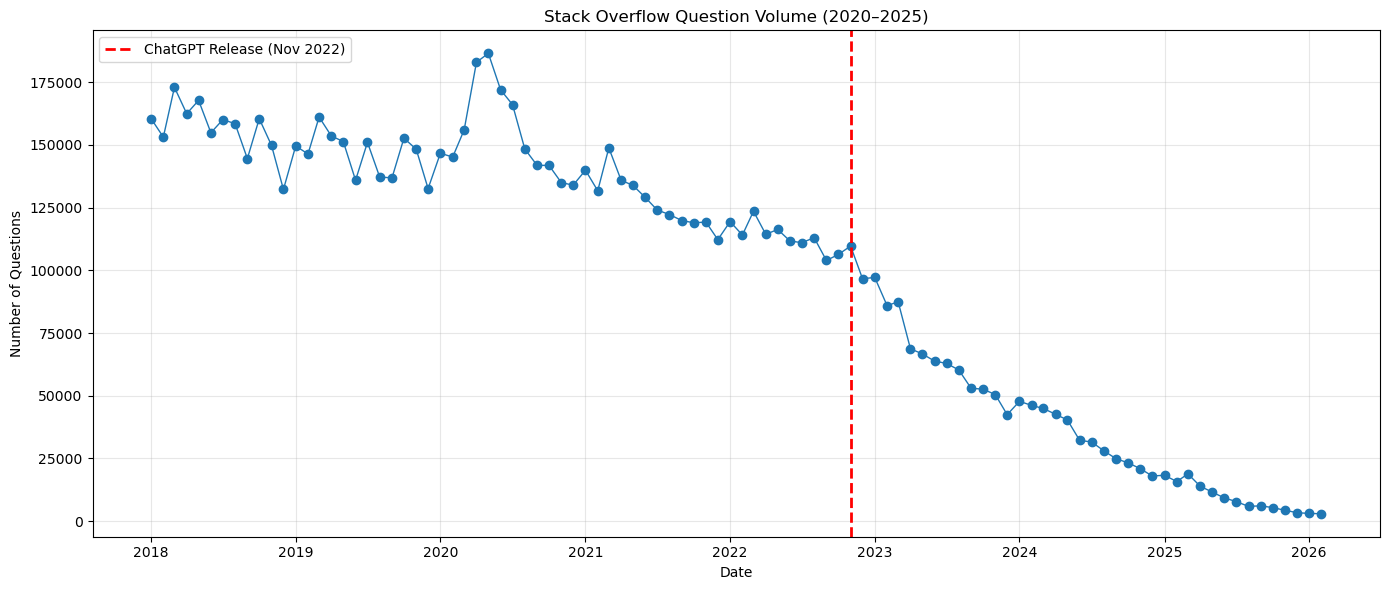

In [5]:
# Make a real date column (first day of each month)
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"],
    df["NumQuestions"],
    marker="o",
    linewidth=1
)

# Vertical line for ChatGPT release (Nov 2022)
plt.axvline(
    pd.Timestamp("2022-11-01"),
    color = 'red',
    linestyle="--",
    linewidth=2,
    label="ChatGPT Release (Nov 2022)"
)

plt.title("Stack Overflow Question Volume (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Number of Questions")

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### **Timeline of Top AI Chatbots**

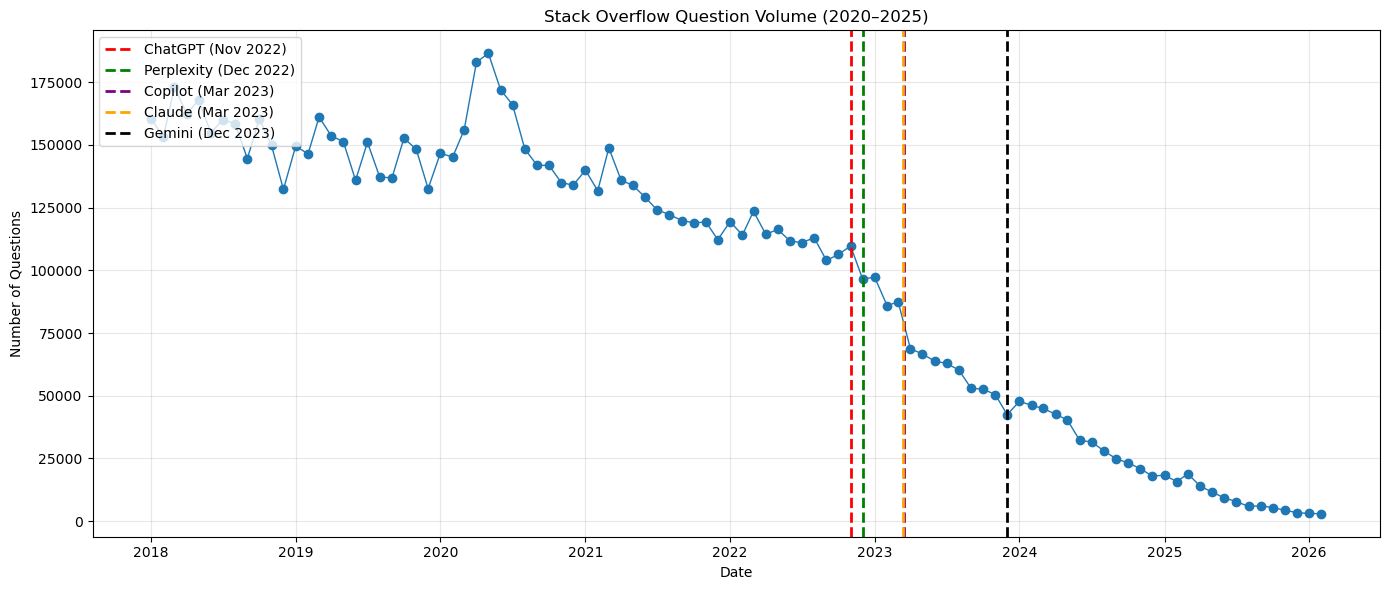

In [6]:
# Make a real date column (first day of each month)
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"],
    df["NumQuestions"],
    marker="o",
    linewidth=1
)

# --- AI chatbot release lines ---

# ChatGPT
plt.axvline(pd.Timestamp("2022-11-01"),
            color="red", linestyle="--", linewidth=2,
            label="ChatGPT (Nov 2022)")

# Perplexity
plt.axvline(pd.Timestamp("2022-12-01"),
            color="green", linestyle="--", linewidth=2,
            label="Perplexity (Dec 2022)")

# Microsoft Copilot (June 2021 preview)
plt.axvline(pd.Timestamp("2023-03-16"),
            color="purple", linestyle="--", linewidth=2,
            label="Copilot (Mar 2023)")
# Claude
plt.axvline(pd.Timestamp("2023-03-14"),
            color="orange", linestyle="--", linewidth=2,
            label="Claude (Mar 2023)")

# Gemini
plt.axvline(pd.Timestamp("2023-12-01"),
            color="black", linestyle="--", linewidth=2,
            label="Gemini (Dec 2023)")

# --- labels ---
plt.title("Stack Overflow Question Volume (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Number of Questions")

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### **Evaluating Statistical Significance (Pre vs. Post ChatGPT)**

In [7]:
cutoff = pd.Timestamp("2022-11-01")

df["Period"] = df["Date"].apply(
    lambda x: "Pre-AI" if x < cutoff else "Post-AI"
)
df.groupby("Period")["NumQuestions"].mean()



pre = df[df["Period"]=="Pre-AI"]["NumQuestions"]
post = df[df["Period"]=="Post-AI"]["NumQuestions"]

t_q, p_q = ttest_ind(pre, post, equal_var=False)

print(f"T-statistic: {t_q:.2f}")
print(f"P-value: {p_q:.3e}")

T-statistic: 19.06
P-value: 1.047e-27


### **Interpreting the Results**
The p-value indicates a statistically significant decrease in the volume of questions asked on Stack Overflow following the emergence of ChatGPT. This confirms the initial hypothesis that user reliance on the forum declined.

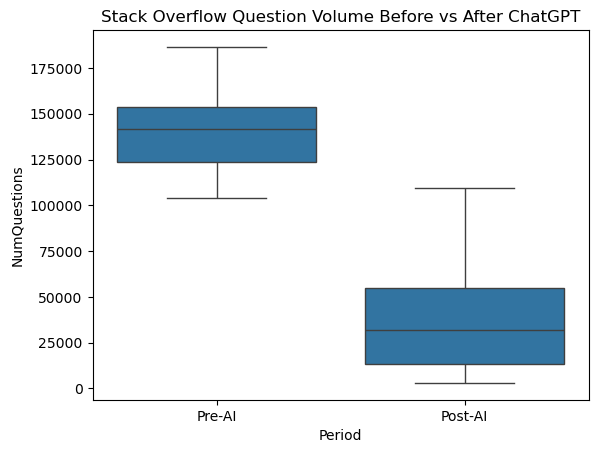

In [8]:
sns.boxplot(data=df, x="Period", y="NumQuestions")
plt.title("Stack Overflow Question Volume Before vs After ChatGPT")
plt.show()

### **Visualizing Pre-AI vs Post-AI Volume**

### **Analyzing Answer Rates Over Time**

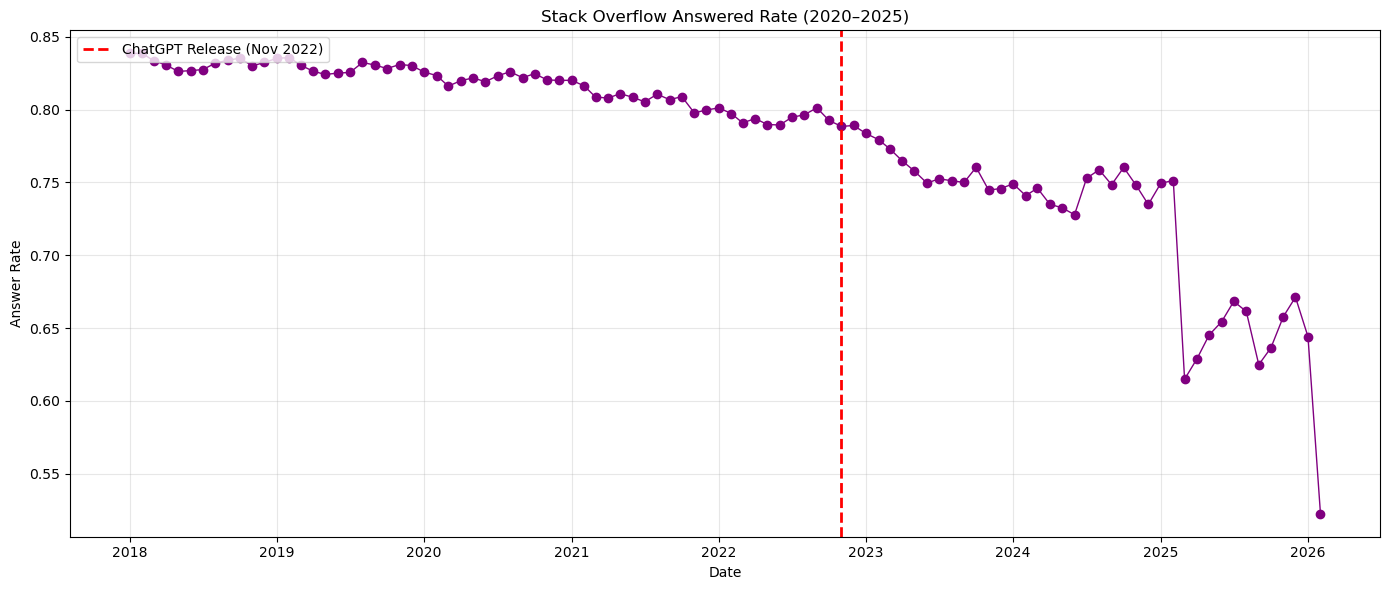

In [9]:
# Make a real date column (first day of each month)
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"],
    df["AnswerRate"],
    color = 'purple',
    marker="o",
    linewidth=1
)

# Vertical line for ChatGPT release (Nov 2022)
plt.axvline(
    pd.Timestamp("2022-11-01"),
    color = 'red',
    linestyle="--",
    linewidth=2,
    label="ChatGPT Release (Nov 2022)"
)

plt.title("Stack Overflow Answered Rate (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Answer Rate")

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### **Interpreting the Results**
The visualization shows that the answer rate experienced a noticeable and sustained decrease following the introduction of major AI chatbots. This trend suggests that as question volume dropped, the remaining questions were less likely to receive answers from the community. The overall engagement from human respondents appears to be waning, indicating a shift where simpler issues that previously garnered quick responses are now being offloaded to AI, leaving harder, more specific questions that fewer users can answer.

In [10]:
pre = df[df["Period"]=="Pre-AI"]["AnswerRate"]
post = df[df["Period"]=="Post-AI"]["AnswerRate"]

t_ar, p_ar = ttest_ind(pre, post, equal_var=False)

print(f"T = {t_ar:.2f}, p = {p_ar:.3e}")

T = 10.19, p = 6.382e-13


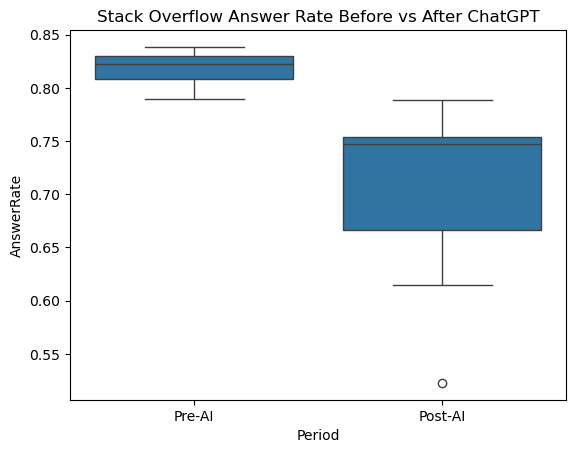

In [11]:
sns.boxplot(data=df, x="Period", y="AnswerRate")
plt.title("Stack Overflow Answer Rate Before vs After ChatGPT")
plt.show()

### **Analyzing Accepted Answer Rates**

Following the same pattern as the general answer rate, the accepted answer rate—the percentage of questions where the original poster definitively marked an answer as correct—also experienced a decline over time. Visualizing this metric allows us to evaluate the quality and utility of the answers still being provided by the community.


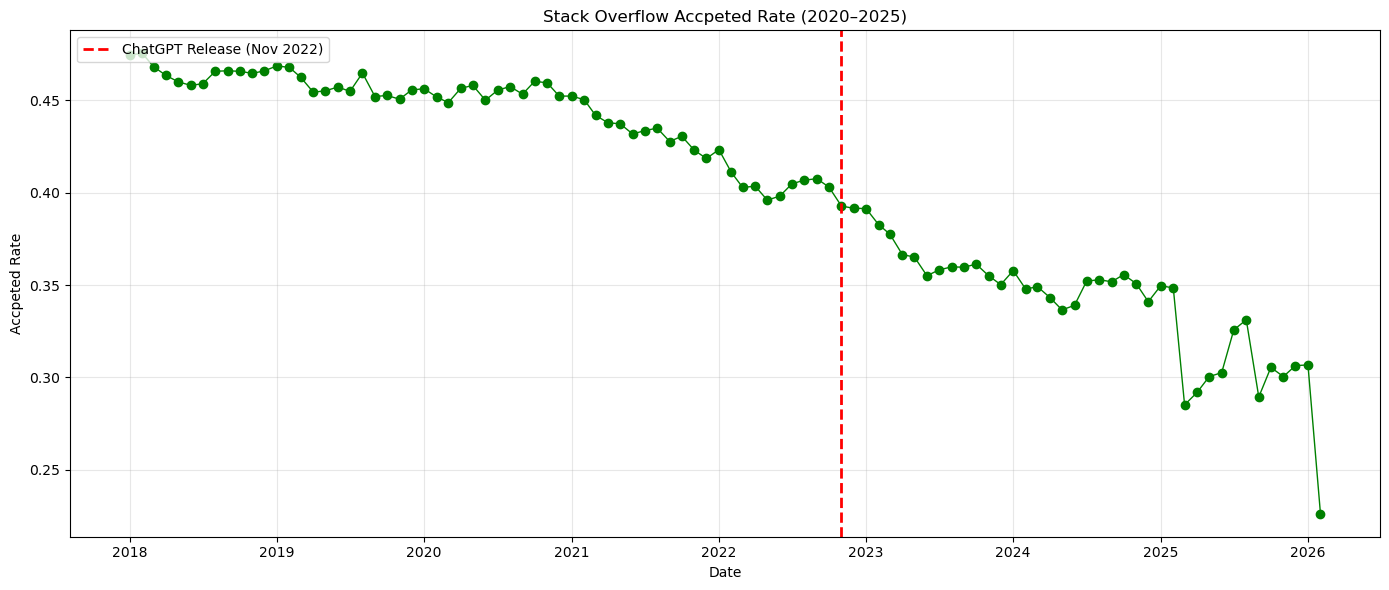

In [12]:
# Make a real date column (first day of each month)
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"],
    df["AcceptedRate"],
    color = 'green',
    marker="o",
    linewidth=1
)

# Vertical line for ChatGPT release (Nov 2022)
plt.axvline(
    pd.Timestamp("2022-11-01"),
    color = 'red',
    linestyle="--",
    linewidth=2,
    label="ChatGPT Release (Nov 2022)"
)

plt.title("Stack Overflow Accpeted Rate (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Accpeted Rate")

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import ttest_ind

pre = df[df["Period"]=="Pre-AI"]["AcceptedRate"]
post = df[df["Period"]=="Post-AI"]["AcceptedRate"]

t_acc, p_acc = ttest_ind(pre, post, equal_var=False)

print(f"T = {t_acc:.2f}, p = {p_acc:.3e}")

T = 17.15, p = 5.016e-25


**Interpreting the Results**
The graph illustrates a clear drop in the accepted answer rate around the releases of ChatGPT and subsequent LLMs. This implies that the community is not only providing fewer answers, but the answers provided are less frequently resolving the user's issue, possibly because users are bringing their most difficult troubleshooting needs to the forum after failing to solve them with an AI.

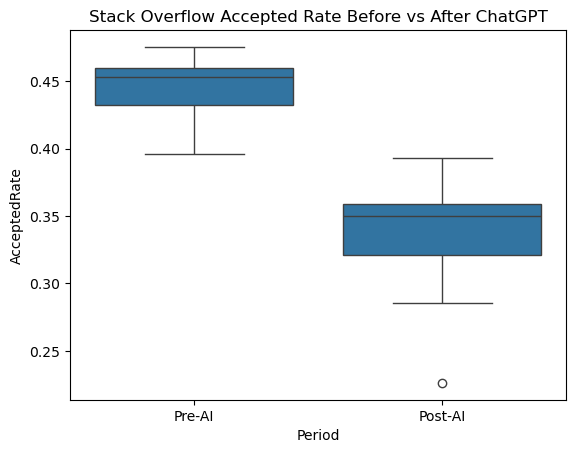

In [14]:
sns.boxplot(data=df, x="Period", y="AcceptedRate")
plt.title("Stack Overflow Accepted Rate Before vs After ChatGPT")
plt.show()

### **Time to Accepted Answer Trends**

Beyond volume and percentages, the *speed* of community assistance is a vital metric. This section visualizes the average time (in minutes) it takes for a question to receive an accepted answer.


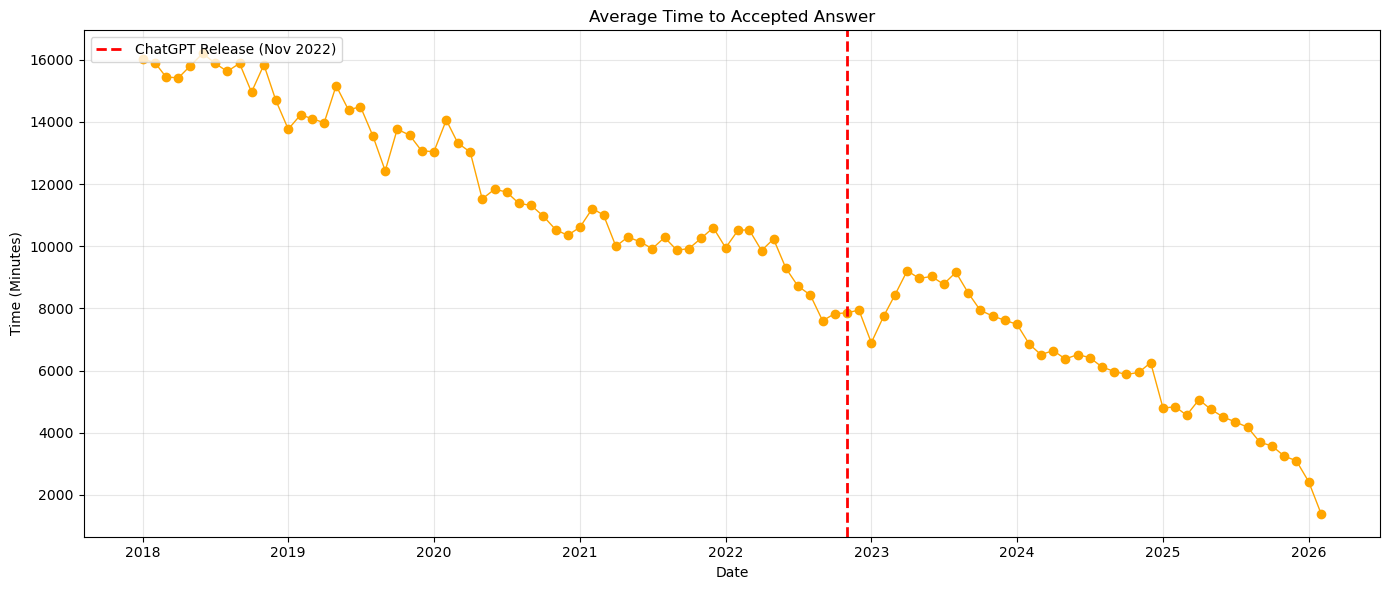

In [15]:
# Make a real date column (first day of each month)
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"],
    df["AvgMinutesToAccepted"],
    color = 'orange',
    marker="o",
    linewidth=1
)

# Vertical line for ChatGPT release (Nov 2022)
plt.axvline(
    pd.Timestamp("2022-11-01"),
    color = 'red',
    linestyle="--",
    linewidth=2,
    label="ChatGPT Release (Nov 2022)"
)

plt.title("Average Time to Accepted Answer")
plt.xlabel("Date")
plt.ylabel("Time (Minutes)")

plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [16]:
pre = df[df["Period"]=="Pre-AI"]["AvgMinutesToAccepted"]
post = df[df["Period"]=="Post-AI"]["AvgMinutesToAccepted"]

t_time, p_time = ttest_ind(pre, post, equal_var=False)

print(f"T = {t_time:.2f}, p = {p_time:.3e}")

T = 13.60, p = 8.381e-24


**Interpreting the Results**
A change in response time indicates that either questions are becoming more complex, or there are fewer active experts available to resolve them quickly. The timeline shows fluctuations that coincide with the shift in platform usage, suggesting that the velocity of knowledge-sharing has slowed down in the post-AI era.

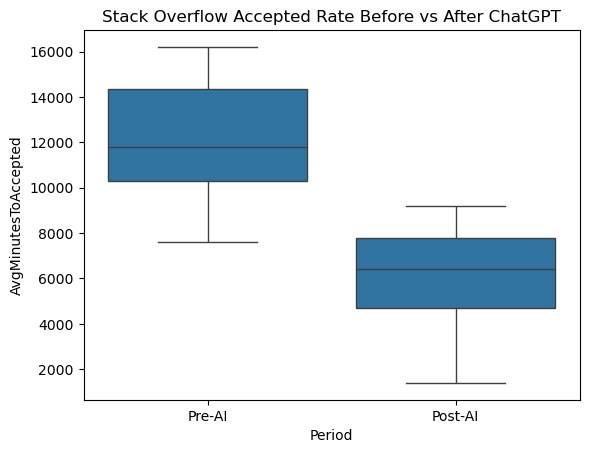

In [17]:
sns.boxplot(data=df, x="Period", y="AvgMinutesToAccepted")
plt.title("Stack Overflow Accepted Rate Before vs After ChatGPT")
plt.show()

### **Comparing Means: Pre-AI vs. Post-AI**

By comparing the statistical means of these metrics before and after the release of ChatGPT, we can quantify the exact magnitude of the shift. 

### **Interpreting the Results**
The statistical comparison confirms that across the board—whether looking at question volume, answer rates, or accepted answer rates—there is a measurable drop in community engagement. The means for the post-AI period are visibly lower. This provides solid empirical evidence that the introduction of conversational AI disrupted the traditional forum-based Q&A ecosystem.

In [18]:
pre_q = df[df["Period"]=="Pre-AI"]["NumQuestions"]
post_q = df[df["Period"]=="Post-AI"]["NumQuestions"]

pre_ar = df[df["Period"]=="Pre-AI"]["AnswerRate"]
post_ar = df[df["Period"]=="Post-AI"]["AnswerRate"]

pre_acc = df[df["Period"]=="Pre-AI"]["AcceptedRate"]
post_acc = df[df["Period"]=="Post-AI"]["AcceptedRate"]

pre_time = df[df["Period"]=="Pre-AI"]["AvgMinutesToAccepted"]
post_time = df[df["Period"]=="Post-AI"]["AvgMinutesToAccepted"]

In [19]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Question Volume",
        "Answer Rate",
        "Accepted Rate",
        "Time to Accepted Answer"
    ],
    "Pre-AI Mean": [
        round(pre_q.mean(), 3),
        round(pre_ar.mean(), 3),
        round(pre_acc.mean(), 3),
        round(pre_time.mean(), 3)
    ],
    "Post-AI Mean": [
        round(post_q.mean(), 3),
        round(post_ar.mean(), 3),
        round(post_acc.mean(), 3),
        round(post_time.mean(), 3)
    ],
    "T-statistic": [
        round(t_q,2),
        round(t_ar,2),
        round(t_acc,2),
        round(t_time,2)
    ],
    "P-value": [
        f"{p_q:.3e}",
        f"{p_ar:.3e}",
        f"{p_acc:.3e}",
        f"{p_time:.3e}"
    ]
})

results

,Metric,Pre-AI Mean,Post-AI Mean,T-statistic,P-value
0,Question Volume,140690.293,38106.525,19.06,1.047e-27
1,Answer Rate,0.818,0.719,10.19,6.382e-13
2,Accepted Rate,0.445,0.340,17.15,5.016e-25
3,Time to Accepted Answer,12316.052,6180.400,13.60,8.381e-24


## **Overall Findings**

Across multiple metrics, the analysis indicates measurable changes in Stack Overflow activity after the release of modern AI chatbots.

Specifically:
Question volume decreased \
Answer rate declined \
Accepted answer rate decreased \
Time to accepted answer changed

These patterns suggest that AI tools may be altering how programmers seek help. Instead of posting questions in online forums, users may increasingly rely on AI systems that provide immediate answers.

However, this analysis identifies correlations rather than causal relationships, and other factors may also influence these trends.

# **Conclusion**

This analysis examined changes in Stack Overflow activity between 2018 and 2025, with a focus on the potential impact of AI chatbots.

The results suggest that the emergence of AI assistants such as ChatGPT may be associated with a decline in traditional forum-based problem solving.

While Stack Overflow remains a major programming resource, AI systems may increasingly serve as an alternative source of technical support.

Further research could explore:

*   user retention patterns
*   new vs returning users
*   topic-level changes in questions
*   programming language trends









